# CLustering

**Data Preprocessing:**

Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.


Use multiple visualizations to understand the hidden patterns in the dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#read excel file
df=pd.read_excel('/content/drive/MyDrive/EastWestAirlines.xlsx',sheet_name='data')

In [ ]:
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [ ]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [ ]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [ ]:
df.shape

(3999, 12)

In [ ]:
#checking null values
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


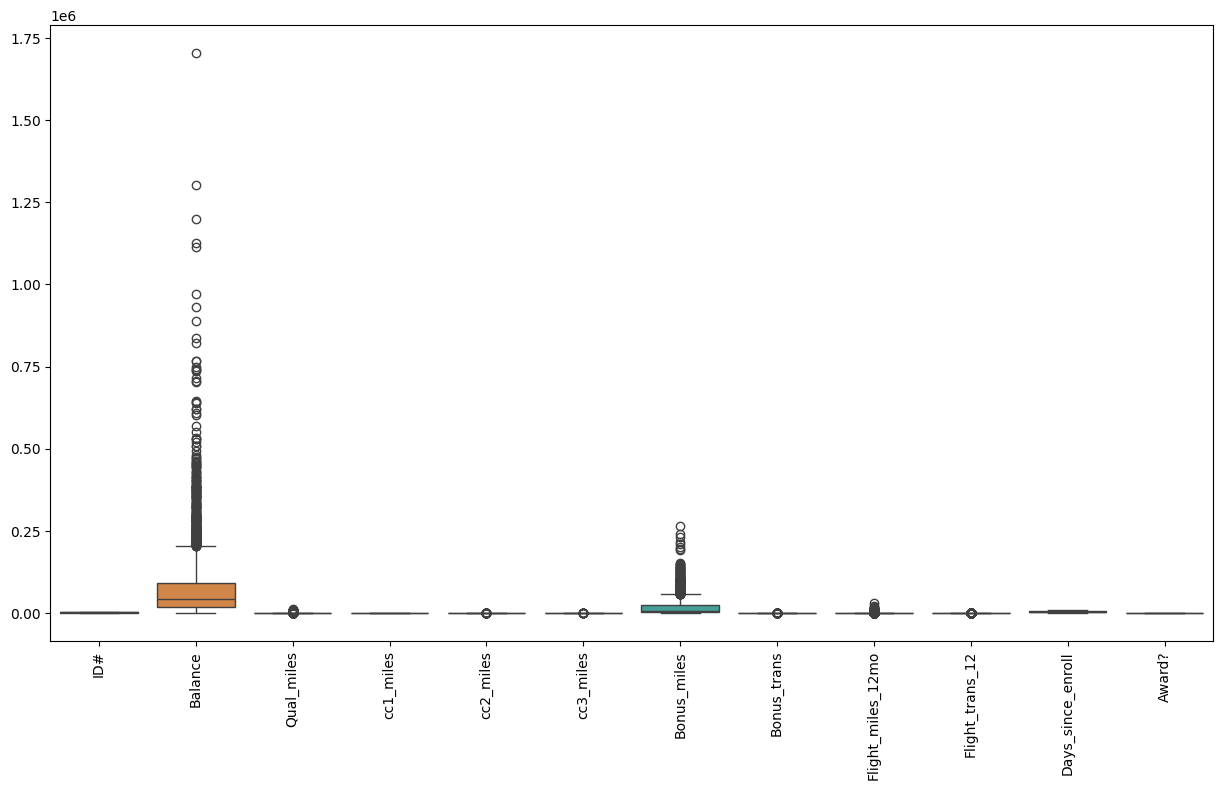

In [ ]:
#detect outlier
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

In [ ]:
#removing outlier
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df_clean = df[
~((df < (Q1 - 1.5*IQR)) |
(df > (Q3 + 1.5*IQR))).any(axis=1)
]

print(df_clean.shape)

(2875, 12)


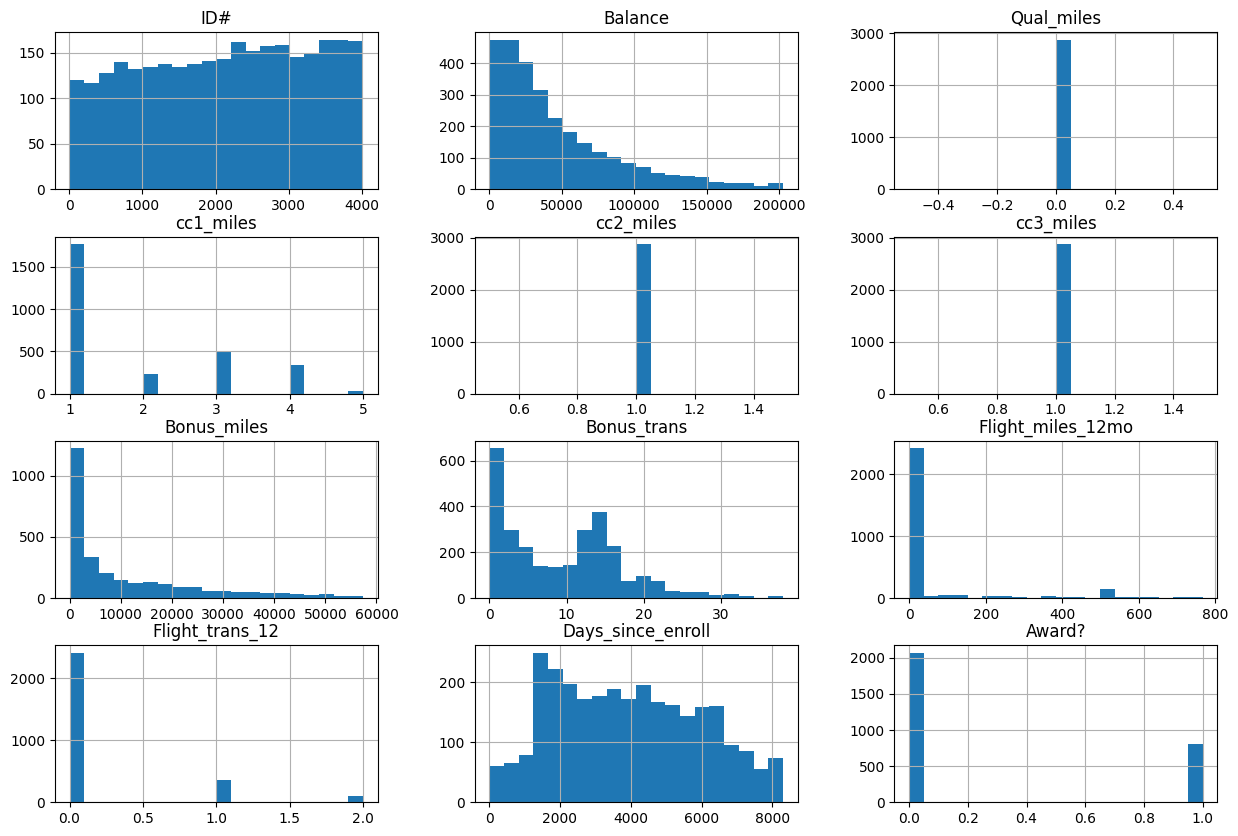

In [ ]:
#feature distribution
#histogram
df_clean.hist(
figsize=(15,10),
bins=20
)

plt.show()

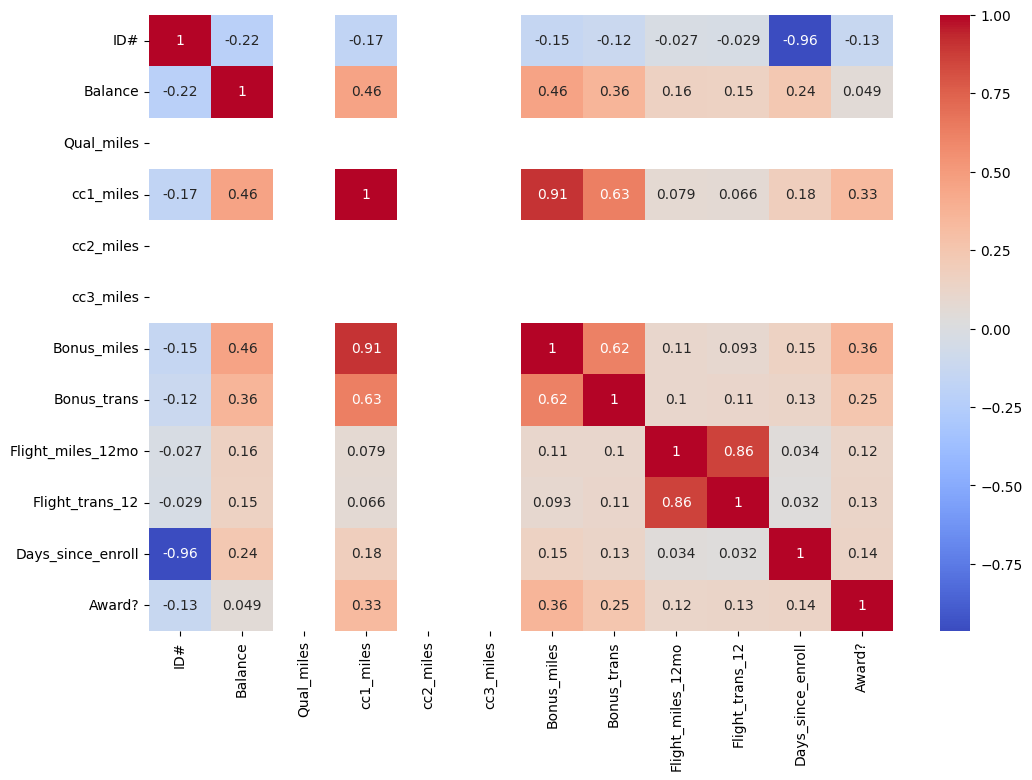

In [ ]:
#correlation analysis
plt.figure(figsize=(12,8))

sns.heatmap(
df_clean.corr(),
annot=True,
cmap="coolwarm"
)

plt.show()

Strong positive correlation:

Bonus Miles  Bonus Transactions
Balance  Bonus Miles

Weak correlations:

Award and Flight Miles

In [ ]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_clean)

**Implementing Clustering Algorithms:**
Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.

Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.



In [ ]:
#Find Optimal K using Elbow Method
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

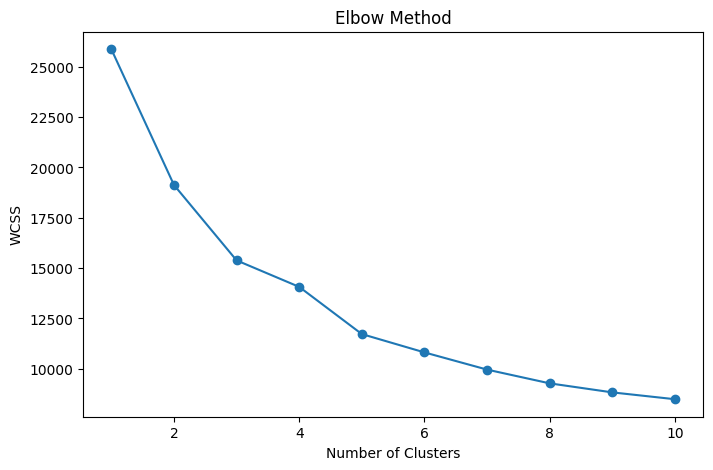

In [ ]:
#Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
range(1,11),
wcss,
marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [ ]:
#Apply KMean
kmeans = KMeans(
n_clusters=4,
random_state=42
)

kmeans_labels = kmeans.fit_predict(
scaled_data
)

In [ ]:
#Silhouette Score
from sklearn.metrics import silhouette_score

sil_kmeans = silhouette_score(
scaled_data,
kmeans_labels
)

print(sil_kmeans)

0.28357826594485636


In [ ]:
# dbcn apply
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
eps=1.5,
min_samples=10
)

dbscan_labels = dbscan.fit_predict(
scaled_data
)

In [ ]:
np.unique(dbscan_labels)

array([-1,  0,  1,  2,  3,  4,  5,  6])

In [ ]:
#Silhouette Score
sil_dbscan = silhouette_score(
scaled_data,
dbscan_labels
)

print(sil_dbscan)

0.14851689488658906


In [ ]:
#Parameter Tuning
eps = [0.5,1,1.5,2]

min_samples = [5,10,15]

In [ ]:
for e in [0.5,1,1.5,2]:

    db = DBSCAN(
    eps=e,
    min_samples=10
    )

    labels = db.fit_predict(
    scaled_data
    )

    print(
    e,
    len(set(labels))
    )

0.5 6
1 7
1.5 8
2 6


In [ ]:
#Task 4: Visualization

In [ ]:
#apply Pca
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(
scaled_data)

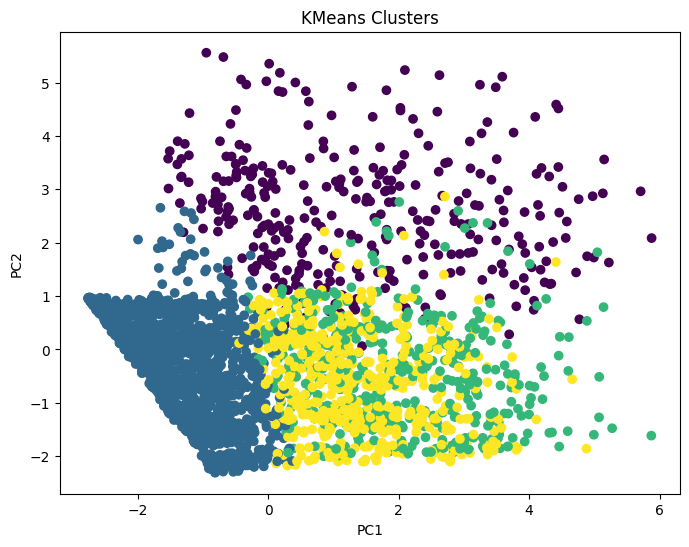

In [ ]:
#KMeans Visualization
plt.figure(figsize=(8,6))

plt.scatter(
pca_data[:,0],
pca_data[:,1],
c=kmeans_labels,
cmap='viridis'
)

plt.title("KMeans Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

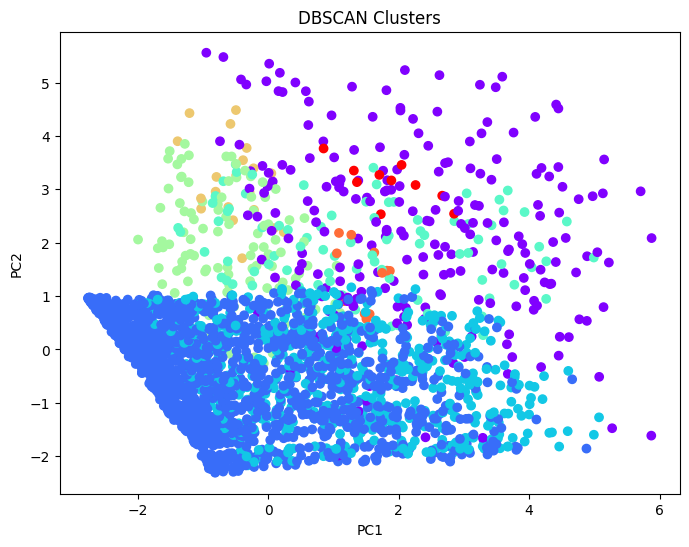

In [ ]:
#dbcn Visualization
plt.figure(figsize=(8,6))

plt.scatter(
pca_data[:,0],
pca_data[:,1],
c=dbscan_labels,
cmap='rainbow'
)

plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
#analysis & Interpretation
#K-Means Cluster Summary
df_clean["Cluster"] = kmeans_labels

cluster_summary = df_clean.groupby(
"Cluster"
).mean()

print(cluster_summary)

                 ID#       Balance  Qual_miles  cc1_miles  cc2_miles  \
Cluster                                                                
0        2018.476744  64769.688953         0.0   1.994186        1.0   
1        2373.380400  26792.235332         0.0   1.052869        1.0   
2        1725.886957  53279.363043         0.0   3.091304        1.0   
3        1745.846154  89080.421154         0.0   2.923077        1.0   

         cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
Cluster                                                            
0              1.0  13810.023256    11.433140         433.133721   
1              1.0   2412.537073     4.911025           4.267569   
2              1.0  25484.302174    15.913043          11.967391   
3              1.0  21239.236538    15.603846           5.765385   

         Flight_trans_12  Days_since_enroll    Award?  
Cluster                                                
0               1.316860        4126.901163  0

/tmp/ipykernel_2406/3867616227.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Cluster"] = kmeans_labels


In [ ]:
#Evaluation Metrics
print("KMeans :",sil_kmeans)

print("DBSCAN :",sil_dbscan)

KMeans : 0.28357826594485636
DBSCAN : 0.14851689488658906
